
--- ESCENARIO 1: CAPACIDAD FIJA ---
Día 1: Demanda=11, Capacidad=10, Backlog=1
Día 2: Demanda=8, Capacidad=10, Backlog=0
Día 3: Demanda=11, Capacidad=10, Backlog=1
Día 4: Demanda=6, Capacidad=10, Backlog=0
Día 5: Demanda=11, Capacidad=10, Backlog=1
Día 6: Demanda=12, Capacidad=10, Backlog=3
Día 7: Demanda=6, Capacidad=10, Backlog=0
Día 8: Demanda=7, Capacidad=10, Backlog=0
Día 9: Demanda=5, Capacidad=10, Backlog=0
Día 10: Demanda=14, Capacidad=10, Backlog=4
Día 11: Demanda=8, Capacidad=10, Backlog=2
Día 12: Demanda=13, Capacidad=10, Backlog=5
Día 13: Demanda=13, Capacidad=10, Backlog=8
Día 14: Demanda=11, Capacidad=10, Backlog=9
Día 15: Demanda=6, Capacidad=10, Backlog=5
Día 16: Demanda=6, Capacidad=10, Backlog=1
Día 17: Demanda=9, Capacidad=10, Backlog=0
Día 18: Demanda=13, Capacidad=10, Backlog=3
Día 19: Demanda=15, Capacidad=10, Backlog=8
Día 20: Demanda=6, Capacidad=10, Backlog=4
Día 21: Demanda=9, Capacidad=10, Backlog=3
Día 22: Demanda=6, Capacidad=10, Backlog=0
Día 23: Demanda=

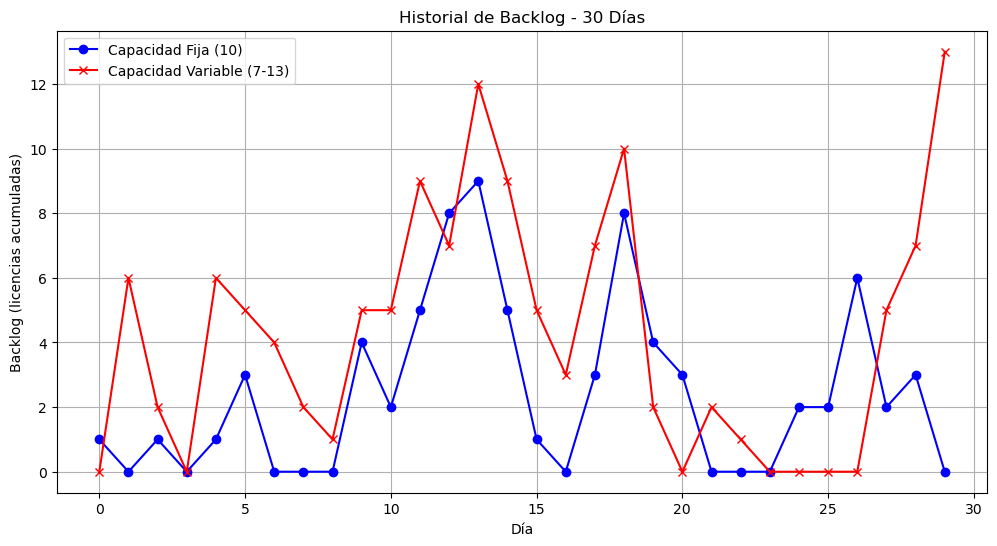

El backlog final con CAPACIDAD VARIABLE es MAYOR


In [4]:
# =========================================
# SIMULACIÓN DE BACKLOG - SaaS
# =========================================

import random
import matplotlib.pyplot as plt

# -------------------------------
# PARÁMETROS DEL MODELO
# -------------------------------

DIAS = 30

DEMANDA_MIN = 5
DEMANDA_MAX = 15

CAPACIDAD_FIJA = 10

CAPACIDAD_VAR_MIN = 7
CAPACIDAD_VAR_MAX = 13

# -------------------------------
# FUNCIÓN: generar demanda diaria
# -------------------------------

def generar_demanda():
    return random.randint(DEMANDA_MIN, DEMANDA_MAX)   

# -------------------------------
# FUNCIÓN: generar capacidad variable
# -------------------------------

def generar_capacidad_variable():
    return random.randint(CAPACIDAD_VAR_MIN, CAPACIDAD_VAR_MAX)

# -------------------------------
# FUNCIÓN PRINCIPAL DE SIMULACIÓN
# -------------------------------

def simular(capacidad_fija=True):  
    
    backlog = 0
    historial_backlog = []

    for dia in range(1, DIAS + 1):

        demanda = generar_demanda()

        if capacidad_fija:
            capacidad = CAPACIDAD_FIJA
        else:
            capacidad = generar_capacidad_variable()

        backlog = backlog + demanda - capacidad

        if backlog < 0:
            backlog = 0

        historial_backlog.append(backlog)

        print(f"Día {dia}: Demanda={demanda}, Capacidad={capacidad}, Backlog={backlog}")

    return backlog, historial_backlog

# -------------------------------
# EJECUCIÓN DE ESCENARIOS
# -------------------------------

print("\n--- ESCENARIO 1: CAPACIDAD FIJA ---")
resultado_fijo, historial_fijo = simular(capacidad_fija=True)   # ✅ simular

print("\n--- ESCENARIO 2: CAPACIDAD VARIABLE ---")
resultado_variable, historial_variable = simular(capacidad_fija=False)   # ✅ simular

# -------------------------------
# COMPARACIÓN FINAL
# -------------------------------

print("\nRESULTADOS FINALES:")
print(f"Backlog final (fijo): {resultado_fijo}")
print(f"Backlog final (variable): {resultado_variable}")

# -------------------------------
# GRÁFICO DE HISTORIAL DE BACKLOG 
# -------------------------------

plt.figure(figsize=(12, 6))
plt.plot(historial_fijo, label="Capacidad Fija (10)", color='blue', marker='o')
plt.plot(historial_variable, label="Capacidad Variable (7-13)", color='red', marker='x')
plt.title("Historial de Backlog - 30 Días")
plt.xlabel("Día")
plt.ylabel("Backlog (licencias acumuladas)")
plt.legend()
plt.grid()
plt.show()

# -------------------------------
# CONCLUSIÓN
# -------------------------------

if resultado_fijo > resultado_variable:
    print("El backlog final con CAPACIDAD FIJA es MAYOR")
elif resultado_variable > resultado_fijo:
    print("El backlog final con CAPACIDAD VARIABLE es MAYOR")
else:
    print("Ambos escenarios tienen el MISMO backlog")